In [1]:
import sys
sys.path.append('../')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
f_theta_1ncut = pd.read_csv('data/other/data_xgate_theta_1ncut.txt')
f_phi_1ncut = pd.read_csv('data/other/data_xgate_phi_1ncut.txt')
f_theta = pd.read_csv('data/data_xgate_theta_3ncut.txt')
f_phi = pd.read_csv('data/data_xgate_phi_3ncut.txt')
pd.set_option('display.precision', 8)

In [2]:
# pa = np.column_stack((f_phi.to_numpy(), np.round(f_500, 8), np.round(f_400, 8),  np.round(f_300, 8), np.round(f_157, 8), np.round(f_157_low, 8)))
# df = pd.DataFrame(pa, columns=['tg', 'drive_amp_1', 'drive_amp_2', 'detune_1', 'detune_2', 'f_160',
#                                'f_500', 'f_noise_9_2us', 'f_noise_100_5us', 'f_noise_100_50us', 'f_ideal_160',
#                                'f_1000', 'f_truc140_ideal', 'f_truc140_170us', 'f_truc140_30us', 'f_truc140_3us',
#                                'f_500', 'f_400', 'f_300','f_160', 'f_160_low'
#                                ])
# df.to_csv('data/data_xgate_phi_3ncut.txt', sep=',', index=False, header=True)

# pa = np.column_stack((f_theta.to_numpy(), np.round(f_1000, 8), np.round(f_500, 8), np.round(f_400, 8),  np.round(f_300, 8), np.round(f_157, 8), np.round(f_157_low, 8)))
# df = pd.DataFrame(pa, columns=['tg', 'drive_amp_1', 'drive_amp_2', 'detune_1', 'detune_2', 'f_157',
#                                'f_500', 'f_noise_9_2us', 'f_noise_100_5us', 'f_noise_100_50us', 
#                                'f_78', 'f_noise_170us', 'f_noise_30us', 'f_noise_3us',
#                                'f_1000','f_500', 'f_400', 'f_300','f_157', 'f_157_low'
#                                ])
# df.to_csv('data/data_xgate_theta_3ncut.txt', sep=',', index=False, header=True)

In [3]:
A = [np.mean(f_theta[['drive_amp_1']]), np.mean(f_theta[['drive_amp_2']])]
detune = [np.mean(f_theta[['detune_1']]), np.mean(f_theta[['detune_2']])]
print(f' Theta gate:')
print(f'Amplitude: A0={A[0]:.6f}, A1={A[1]:.6f}')
print(f'detune_0={detune[0]:.6f}, detune_1={detune[1]:.6f}')

A = [np.mean(f_phi[['drive_amp_1']]), np.mean(f_phi[['drive_amp_2']])]
detune = [np.mean(f_phi[['detune_1']]), np.mean(f_phi[['detune_2']])]
print(f'\nPhi gate:')
print(f'Amplitude: A0={A[0]:.6f}, A1={A[1]:.6f}')
print(f'detune_0={detune[0]:.6f}, detune_1={detune[1]:.6f}')

 Theta gate:
Amplitude: A0=0.119467, A1=0.028685
detune_0=-0.006975, detune_1=-0.002039

Phi gate:
Amplitude: A0=0.214044, A1=0.120290
detune_0=0.351830, detune_1=0.375322


In [4]:
1 - 10**f_theta[['f_1000', 'f_157', 'f_78']]

,f_1000,f_157,f_78
0,0.66650278,0.66654788,0.67719770
1,0.87107754,0.87136637,0.86782997
2,0.98854626,0.98850830,0.98769151
3,0.99838415,0.99838320,0.99830110
4,0.99956420,0.99956710,0.99954866
5,0.99982848,0.99983130,0.99982424
6,0.99992129,0.99992432,0.99992123
7,0.99996310,0.99996944,0.99996511
8,0.99997809,0.99998397,0.99998059
9,0.99998632,0.99999091,0.99998910


In [5]:
f1 = 1 - 10**f_theta[['f_1000']].to_numpy().flatten()  # 模型1的保真度
f2 = 1 - 10**f_theta[['f_157']].to_numpy().flatten()  # 模型2的保真度
mae2 = np.mean(np.abs(f1 - f2)) # 平均绝对误差
max2 = np.max(np.abs(f1 - f2)) # 最大绝对误差
percent2 = np.abs(f1 - f2)/f1 # 绝对误差 百分比
print(f"MAE: {mae2:.2e}, Max: {max2:.2e}, Percent: {np.mean(percent2):.4%}")
print(np.abs(f1 - f2))

f3 = 1 - 10**f_theta[['f_78']].to_numpy().flatten()  # 模型2的保真度
mae3 = np.mean(np.abs(f1 - f3)) # 平均绝对误差
max3 = np.max(np.abs(f1 - f3)) # 最大绝对误差
percent3 = np.abs(f1 - f3)/f1 # 绝对误差 百分比
print(f"MAE: {mae3:.2e}, Max: {max3:.2e}, Percent: {np.mean(percent3):.4%}")
print(np.abs(f1 - f3))

MAE: 2.35e-05, Max: 2.89e-04, Percent: 0.0027%
[4.51037323e-05 2.88830491e-04 3.79560582e-05 9.55107673e-07
 2.90120125e-06 2.82445093e-06 3.02931920e-06 6.33687348e-06
 5.87562511e-06 4.58370618e-06 3.76583889e-06 3.13579787e-06
 3.13859473e-06 2.91054079e-06 3.02055510e-06 2.87907171e-06
 2.74418447e-06 3.05247720e-06]
MAE: 8.29e-04, Max: 1.07e-02, Percent: 0.1154%
[1.06949218e-02 3.24757156e-03 8.54747269e-04 8.30465156e-05
 1.55469686e-05 4.24039622e-06 6.21679598e-08 2.01058325e-06
 2.49171213e-06 2.78164545e-06 2.75763412e-06 2.44189228e-06
 2.63538863e-06 2.71377577e-06 3.09577188e-06 3.01236358e-06
 3.05602204e-06 3.40194344e-06]


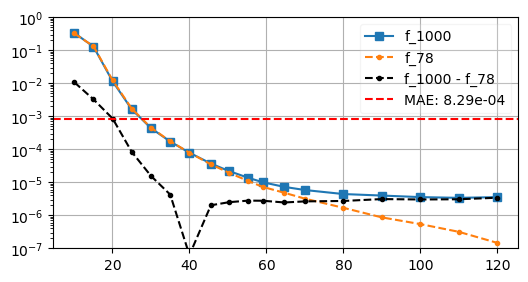

In [6]:
fig, ax = plt.subplots(figsize=(6,3))
plt.plot(f_theta['tg'], 10**f_theta['f_1000'], 's-', label=r'f_1000')
# plt.plot(f_theta['tg'], 10**f_theta['f_500'], 'D--', label=r'f_500')
# plt.plot(f_theta['tg'], 10**f_theta['f_400'], '+--', label=r'f_400')
# plt.plot(f_theta['tg'], 10**f_theta['f_300'], 'v--', label=r'f_300')
# plt.plot(f_theta['tg'], 10**f_theta['f_157'], 'x--', label=r'f_157')
# plt.plot(f_theta['tg'], 10**f_theta['f_157_low'], '.--', label=r'f_157_low')
plt.plot(f_theta['tg'], 10**f_theta['f_78'], '.--', label=r'f_78')

# plt.plot(f_theta['tg'], np.abs(f1 - f2), '.--', label=r'f_1000 - f_157', color='black')
# plt.axhline(y=mae2, color='red', linestyle='--', label=f'MAE: {mae2:.2e}')
plt.plot(f_theta['tg'], np.abs(f1 - f3), '.--', label=r'f_1000 - f_78', color='black')
plt.axhline(y=mae3, color='red', linestyle='--', label=f'MAE: {mae3:.2e}')
plt.yscale('log')
plt.ylim(1e-7, 1e0)
# plt.title(f"Mean Absolute Error: {mae2:.2e}")
# plt.xlabel('Gate Time $t_g$ (ns)')
# plt.ylabel('Gate Error')
plt.grid()
legend = plt.legend(    loc="best",    )
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

In [7]:
1 - 10**f_phi[['f_1000', 'f_160', 'f_truc140_ideal']]

,f_1000,f_160,f_truc140_ideal
0,0.75210508,0.75193955,0.74933783
1,0.82814504,0.82305532,0.83057779
2,0.86956692,0.86977743,0.87275135
3,0.92646315,0.92463016,0.92711585
4,0.96732134,0.96740872,0.96582853
5,0.97709901,0.97699291,0.97712072
6,0.97834211,0.98003166,0.97828726
7,0.97868799,0.98183248,0.97786484
8,0.98631206,0.98571061,0.98723385
9,0.98633994,0.98755033,0.98756956


In [8]:
f1 = 1 - 10**f_phi[['f_1000']].to_numpy().flatten()  # 模型1的保真度
f2 = 1 - 10**f_phi[['f_160']].to_numpy().flatten()  # 模型2的保真度
mae2 = np.mean(np.abs(f1 - f2)) # 平均绝对误差
max2 = np.max(np.abs(f1 - f2)) # 最大绝对误差   
percent2 = np.abs(f1 - f2)/f1 # 绝对误差 百分比
print(f"MAE: {mae2:.2e}, Max: {max2:.2e}, Percent: {np.mean(percent2):.4%}")
print(np.abs(f1 - f2))

f3 = 1 - 10**f_phi[['f_truc140_ideal']].to_numpy().flatten()  # 模型2的保真度
mae3 = np.mean(np.abs(f1 - f3)) # 平均绝对误差
max3 = np.max(np.abs(f1 - f3)) # 最大绝对误差
percent3 = np.abs(f1 - f3)/f1 # 绝对误差 百分比 
print(f"MAE: {mae3:.2e}, Max: {max3:.2e}, Percent: {np.mean(percent3):.4%}")
print(np.abs(f1 - f3))

MAE: 8.17e-04, Max: 5.09e-03, Percent: 0.0892%
[1.65529911e-04 5.08972054e-03 2.10507721e-04 1.83299161e-03
 8.73723066e-05 1.06095539e-04 1.68955455e-03 3.14449219e-03
 6.01457148e-04 1.21039144e-03 1.81027169e-04 2.99644823e-04
 3.40039910e-05 1.87561959e-04 1.46000989e-04 1.39504872e-04
 1.96135829e-04 2.54248770e-05 1.69944039e-04]
MAE: 8.57e-04, Max: 3.18e-03, Percent: 0.0965%
[2.76725110e-03 2.43274666e-03 3.18442520e-03 6.52698422e-04
 1.49281679e-03 2.17066388e-05 5.48475843e-05 8.23145778e-04
 9.21780589e-04 1.22961548e-03 7.17695789e-04 5.09750041e-04
 1.32238230e-04 4.18473424e-04 4.64203167e-04 5.03895540e-05
 2.93133030e-07 2.80243175e-04 1.20702899e-04]


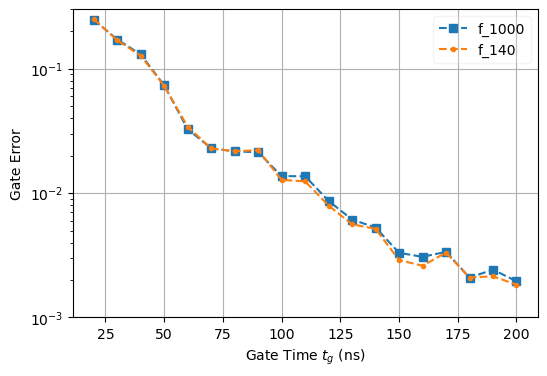

In [9]:
fig, ax = plt.subplots(figsize=(6,4))
plt.plot(f_phi['tg'], 10**f_phi['f_1000'], 's--', label=r'f_1000')
# plt.plot(f_phi['tg'], 10**f_phi['f_500'], 'D--', label=r'f_500')
# plt.plot(f_phi['tg'], 10**f_phi['f_400'], '.--', label=r'f_400')
# plt.plot(f_phi['tg'], 10**f_phi['f_300'], 'v--', label=r'f_300')
# plt.plot(f_phi['tg'], 10**f_phi['f_160'], 'x--', label=r'f_160')
# plt.plot(f_phi['tg'], 10**f_phi['f_160_low'], '.--', label=r'f_160_low')
plt.plot(f_phi['tg'], 10**f_phi['f_truc140_ideal'], '.--', label=r'f_140')

# plt.plot(f_phi['tg'], np.abs(f1 - f2), '.--', label=r'f_1000 - f_160', color='black')
# plt.axhline(y=mae2, color='red', linestyle='--', label=f'MAE: {mae2:.2e}')
# plt.plot(f_phi['tg'], np.abs(f1 - f3), '.--', label=r'f_1000 - f_140', color='black')
# plt.axhline(y=mae3, color='red', linestyle='--', label=f'MAE: {mae3:.2e}')

plt.ylim(1e-3, 3e-1)
plt.yscale('log')
# plt.title(f"Mean Absolute Error: {mae3:.2e}")
# plt.title(r'$n_\phi$')
plt.xlabel('Gate Time $t_g$ (ns)')
plt.ylabel('Gate Error')
plt.grid()
legend = plt.legend(    loc="best",    )
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

In [10]:
f_charge140_170us_v2 = np.array([
-0.603384124030712, -0.9003022322840204, -1.4630289009915025, -1.6569012495088442 ,
-1.8869198520317652, -2.0400081532373058, -2.2497001628206768, -2.512534408255835 ,
-2.505895126775401, -2.6213241163924197 ,
])
f_charge140_30us_v2 = np.array([
-0.6023835948636584, -0.8961866890012773, -1.4372339959804545, -1.6041503976614544 ,
-1.787068214544117, -1.8788895866091895, -1.9879654264077375, -2.0738735911352877 ,
-2.0442747958567145, -2.030625726965328 ,
])
f_charge140_3us_v2 = np.array([
-0.5917115328455644, -0.8544228593648189, -1.2296830011196724, -1.2611639909773373 ,
-1.2887387773541759, -1.2547229760539487, -1.229649123660188, -1.1961381114517318 ,
-1.155311708583152, -1.117491462170848 ,
])
v2_ideal = np.array([
-0.6009112143429436, -0.8953468063786553, -1.46633629292876, -1.6632854175496878 ,
-1.8939398906481715, -2.100645638428869, -2.2880623312778505, -2.5841711750029046 ,
-2.6794524498984034, -2.7365165224563937 ,
])
v2 = np.array([
[20.000087, 0.249753, 0.216297, 0.43883, 0.490612] ,
[40.006173, 0.223179, 0.160035, 0.358809, 0.386917] ,
[60.000967, 0.213711, 0.14419, 0.358967, 0.378127] ,
[80.007155, 0.210573, 0.122946, 0.355789, 0.37113] ,
[100.001683, 0.212233, 0.113924, 0.340021, 0.36258] ,
[120.004766, 0.209273, 0.104767, 0.341188, 0.360503] ,
[140.008725, 0.211735, 0.099358, 0.338134, 0.362321] ,
[160.000656, 0.209132, 0.090941, 0.337889, 0.359183] ,
[180.006237, 0.21108, 0.084566, 0.335734, 0.36059] ,
[200.005395, 0.208582, 0.081626, 0.335171, 0.357777] ,
])
v2tot = np.column_stack((v2, np.round(v2_ideal, 8), np.round(f_charge140_170us_v2, 8),
                         np.round(f_charge140_30us_v2, 8), np.round(f_charge140_3us_v2, 8) ))


In [11]:
f_charge140_170us_v3 = np.array([
-0.7761794330039011, -1.136974068566397, -1.6364561843108747, -1.649779365007976 ,
-1.9034720838457102, -2.1778548157427653, -2.4709933233521295, -2.3745061013160864 ,
-2.63398540043164 ,
])
f_charge140_30us_v3 = np.array([
-0.7738740011678911, -1.1275068993090454, -1.5926022942046747, -1.5934061361700882 ,
-1.7894363129283495, -1.9524905261080059, -2.068837875672322, -2.003601523219357 ,
-2.0603941827210117 ,
])
f_charge140_3us_v3 = np.array([
-0.7500017009370954, -1.037398163551171, -1.2883504158910843, -1.2360655677120598 ,
-1.2589640548056762, -1.2396064632792754, -1.2149204233039894, -1.171424405728427 ,
-1.138361377642085 ,
])
v3_ideal = np.array([
-0.7710296520870434, -1.137366901124569, -1.6405575650317505, -1.6549173821223386 ,
-1.9055133720239796, -2.250809546974744, -2.5388987862677066, -2.4791309644505026 ,
-2.6693074486470736 ,
])
v3 = np.array([
[30.002512, 0.222626, 0.201971, 0.389445, 0.425332] ,
[50.000191, 0.215248, 0.148153, 0.354356, 0.376483] ,
[70.001044, 0.209788, 0.131851, 0.353189, 0.36997] ,
[90.009744, 0.219753, 0.113433, 0.351332, 0.376525] ,
[110.009928, 0.211658, 0.106989, 0.341806, 0.362874] ,
[130.002315, 0.201238, 0.098495, 0.3428, 0.353056] ,
[150.002399, 0.205268, 0.094552, 0.339607, 0.355509] ,
[170.00663, 0.212306, 0.087921, 0.33633, 0.362475] ,
[190.009275, 0.209698, 0.083495, 0.335382, 0.359146] ,
])
v3tot = np.column_stack((v3, np.round(v3_ideal, 8), np.round(f_charge140_170us_v3, 8),
                         np.round(f_charge140_30us_v3, 8), np.round(f_charge140_3us_v3, 8) ))
arr = np.row_stack((v2tot, v3tot))
sorted_arr = arr[np.argsort(arr[:, 0])]
for i in range(len(sorted_arr)):
    print(sorted_arr[i].tolist(), ',')

[20.000087, 0.249753, 0.216297, 0.43883, 0.490612, -0.60091121, -0.60338412, -0.60238359, -0.59171153] ,
[30.002512, 0.222626, 0.201971, 0.389445, 0.425332, -0.77102965, -0.77617943, -0.773874, -0.7500017] ,
[40.006173, 0.223179, 0.160035, 0.358809, 0.386917, -0.89534681, -0.90030223, -0.89618669, -0.85442286] ,
[50.000191, 0.215248, 0.148153, 0.354356, 0.376483, -1.1373669, -1.13697407, -1.1275069, -1.03739816] ,
[60.000967, 0.213711, 0.14419, 0.358967, 0.378127, -1.46633629, -1.4630289, -1.437234, -1.229683] ,
[70.001044, 0.209788, 0.131851, 0.353189, 0.36997, -1.64055757, -1.63645618, -1.59260229, -1.28835042] ,
[80.007155, 0.210573, 0.122946, 0.355789, 0.37113, -1.66328542, -1.65690125, -1.6041504, -1.26116399] ,
[90.009744, 0.219753, 0.113433, 0.351332, 0.376525, -1.65491738, -1.64977937, -1.59340614, -1.23606557] ,
[100.001683, 0.212233, 0.113924, 0.340021, 0.36258, -1.89393989, -1.88691985, -1.78706821, -1.28873878] ,
[110.009928, 0.211658, 0.106989, 0.341806, 0.362874, -1.90551

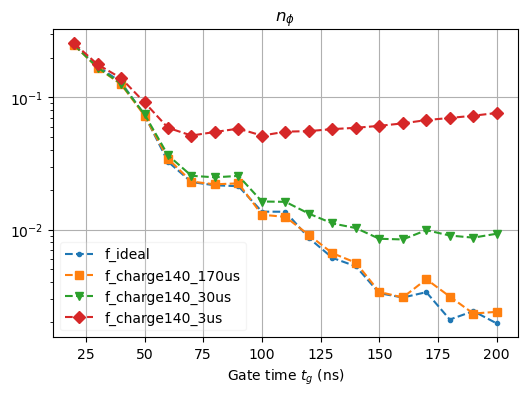

In [12]:
fig, ax = plt.subplots(figsize=(6,4))
plt.plot(f_phi['tg'], 10**f_phi['f_1000'], '.--', label=r'f_ideal')
# plt.plot(f_phi['tg'], 10**sorted_arr[:,5], 's--', label=r'f_charge140_ideal')
plt.plot(f_phi['tg'], 10**sorted_arr[:,6], 's--', label=r'f_charge140_170us')
plt.plot(f_phi['tg'], 10**sorted_arr[:,7], 'v--', label=r'f_charge140_30us')
plt.plot(f_phi['tg'], 10**sorted_arr[:,8], 'D--', label=r'f_charge140_3us')


plt.yscale('log')
plt.title(r'$n_\phi$')
plt.xlabel('Gate time $t_g$ (ns)')
plt.grid()
legend = plt.legend(    loc="best",    )
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

In [13]:
f_70_all = np.array([
-0.5766486851411565, -0.5834070487120887, -0.96091571160584, -1.2264790705142403 ,
-1.301624431089364, -1.5753777669062592, -1.4674855426000768, -1.4430303673326017 ,
-2.175550163132439, -2.0640454013049423, -2.117625762023804, -2.290636350340953 ,
-2.2335154341459784, -2.4476959588692155, -2.4453862078274167, -2.4545139271908214 ,
-2.5877571822657575, -2.6654566750154975, -2.737259465708176 ,
])
f_80_all = np.array([
-0.6010501486332847, -0.6551607900799474, -0.9568820329422421, -1.1326151998345757 ,
-1.3633705456301022, -1.5827261938172241, -1.5764086187106432, -1.4751418741997595 ,
-2.1641406960389014, -2.033645336627922, -2.1130054878749056, -2.1200424000665534 ,
-2.2079914819894286, -2.3943202646893362, -2.357101231798481, -2.365905073300403 ,
-2.460497979865641, -2.597623755435201, -2.6751576491777045 ,
])
f_90_all = np.array([
-0.548566367020395, -0.6596026774549671, -0.8474157463352698, -1.0384347700223913 ,
-1.3547559146956107, -1.496713416413395, -1.4915819418833127, -1.5371720875681336 ,
-2.1229698363002885, -1.965774338733258, -2.070504321883077, -2.1267307533627533 ,
-2.294569081160258, -2.5096320774866756, -2.5075648889745508, -2.460082743997009 ,
-2.6688524899451522, -2.721422914495329, -2.8345402486021114 ,
])
f_100_all = np.array([
-0.548566367020395, -0.6596026774549671, -0.8474157463352698, -1.0384347700223913 ,
-1.3547559146956107, -1.496713416413395, -1.4915819418833127, -1.5371720875681336 ,
-2.1229698363002885, -1.965774338733258, -2.070504321883077, -2.1267307533627533 ,
-2.294569081160258, -2.5096320774866756, -2.5075648889745508, -2.460082743997009 ,
-2.6688524899451522, -2.721422914495329, -2.8345402486021114 ,
])
f_70_short = np.array([
-0.5766486851411565, -0.5834070487120887, -0.96091571160584, -1.2264790705142403 ,
-1.301624431089364, -1.5753777669062592, -1.4674855426000768, -1.4430303673326017 ,
-2.175550163132439, -2.0640454013049423, -2.117625762023804, -2.290636350340953 ,
-2.2335154341459784, -2.4476959588692155, -2.4453862078274167, -2.4545139271908214 ,
-2.5877571822657575, -2.6654566750154975, -2.737259465708176 ,
])
f_80_short = np.array([
-0.6010501486332847, -0.6551607900799474, -0.9568820329422421, -1.1326151998345757 ,
-1.3633705456301022, -1.5827261938172241, -1.5764086187106432, -1.4751418741997595 ,
-2.1641406960389014, -2.033645336627922, -2.1130054878749056, -2.1200424000665534 ,
-2.2079914819894286, -2.3943202646893362, -2.357101231798481, -2.365905073300403 ,
-2.460497979865641, -2.597623755435201, -2.6751576491777045 ,
])
f_130_all = np.array([
-0.5747498450504359, -0.600966241719692, -0.8395997576604729, -1.080530686701608 ,
-1.459266321525219, -1.6090175424908097, -1.6606340137874425, -1.6457091368668624 ,
-1.9005915104622717, -1.887552260406465, -2.0546352670980514, -2.220905334275262 ,
-2.262661857520571, -2.3415309374444413, -2.394243485059904, -2.401678661540734 ,
-2.7689382035273953, -2.678053019894696, -2.905020828832816 ,
])
f_150_all = np.array([
-0.593678965826093, -0.7089764356089837, -0.8492962729916617, -1.0954833879813424 ,
-1.5055728765540333, -1.6243058518562925, -1.67824479012166, -1.7231077320237922 ,
-1.868237589021292, -1.9042348849618957, -2.088559632306603, -2.2239478645604573 ,
-2.262413035772211, -2.562397055364524, -2.5785941826944456, -2.4436729726787068 ,
-2.7146731600351584, -2.6437667850984075, -2.8224996753531877 ,
])
f_100_short = np.array([
-0.548566367020395, -0.6596026774549671, -0.8474157463352698, -1.0384347700223913 ,
-1.3547559146956107, -1.496713416413395, -1.4915819418833127, -1.5371720875681336 ,
-2.1229698363002885, -1.965774338733258, -2.070504321883077, -2.1267307533627533 ,
-2.294569081160258, -2.5096320774866756, -2.5075648889745508, -2.460082743997009 ,
-2.6688524899451522, -2.721422914495329, -2.8345402486021114 ,
])
f_all300_160 = np.array([
-0.6054424763800341, -0.7521624851173503, -0.8853137397743029, -1.122802399581572 ,
-1.4868985166151467, -1.6381383777639675, -1.6996581384233214, -1.740704356667238 ,
-1.8449862311781318, -1.90484224195722, -2.0722114065597106, -2.1923070113867147 ,
-2.2798587869038682, -2.4562560618811813, -2.5341223555727805, -2.454960428041847 ,
-2.640586764886095, -2.620478305588591, -2.672640596132199 ,
])
f_charge_140 = np.array([
-0.6009112143429436, -0.7710296520870427, -0.8953468063786553, -1.137366901124569 ,
-1.46633629292876, -1.6405575650317505, -1.6632854175496878, -1.6549173821223386 ,
-1.8939398906481715, -1.9055133720239679, -2.100645638428869, -2.2508095469747182 ,
-2.2880623312778505, -2.53889878626774, -2.5841711750029046, -2.4791309644504884 ,
-2.6794524498984034, -2.6693074486470056, -2.7365165224563937 ,
])
f_charge_120 = np.array([
-0.5841178309505569, -0.6663166297180771, -0.8913034719396453, -1.0765230929636416 ,
-1.342615950574348, -1.561775753777561, -1.6945921503477506, -1.547401618111052 ,
-1.7626365441514686, -1.8431192906932636, -2.0382033546002707, -2.104913130130719 ,
-2.1905358144971743, -2.163338796868831, -2.28960928799323, -2.4308045838183805 ,
-2.6865114493528535, -2.678271184824923, -2.7163955840395193 ,
])
f_charge_100 = np.array([
-0.5799833016584928, -0.7124246116087807, -0.8229788851574773, -1.0784039655582507 ,
-1.4551432860999687, -1.6015295690263738, -1.6774490372782436, -1.6855308917012626 ,
-1.9372727538010686, -1.9074450606257836, -2.1289879307953967, -1.9772123454666106 ,
-2.2893631513929504, -2.261063406839444, -2.4622228444009306, -2.4874207686934917 ,
-2.7438214399630945, -2.7476037968430846, -2.8168858385144597 ,
])
f_short_140 = np.array([
-0.595940165001755, -0.658442372189959, -0.8402273747273248, -1.088652508812391 ,
-1.4666562022848386, -1.6243470958212274, -1.6799166091515312, -1.7209965998589682 ,
-1.9077493720970309, -1.907342933781571, -2.0918864467872877, -2.247826897944595 ,
-2.2651496720247626, -2.560217605011392, -2.5836513433804704, -2.4376266644068787 ,
-2.7082591307263058, -2.637940628682094, -2.8089242283239804 ,
])
f_short_120 = np.array([
-0.5378277202869093, -0.7270858271978133, -0.8783952395416925, -1.042429975062545 ,
-1.3659885121088031, -1.5097178889999898, -1.580803577111852, -1.5197142772013177 ,
-1.7506325706824306, -1.8700448442830728, -2.05023026790508, -2.1182910804885218 ,
-2.1678623437728826, -2.211118676683449, -2.2904211752406525, -2.3763651386032887 ,
-2.5454410362877002, -2.6145374517444404, -2.6622100338105215 ,
])
f_short_100 = np.array([
-0.5395152562103006, -0.6632203843911195, -0.8229596444783251, -1.0286156688372672 ,
-1.3261072210144702, -1.5287220491524944, -1.5254215273346883, -1.536012209581802 ,
-1.9862868433314584, -1.9965337061845396, -2.0565857511118995, -2.1733906045177536 ,
-2.262599980408071, -2.467832997428105, -2.4900447138480346, -2.459333476836157 ,
-2.721133541834587, -2.7308843892137187, -2.8076338069393154 ,
])

f_all500_200 = np.array([
-0.5967350091125205, -0.7538091822714057, -0.8807346956043616, -1.120084880305557 ,
-1.4811666226972027, -1.6291964502238447, -1.6667599362435213, -1.671487346383281 ,
-1.8517394929999977, -1.859107460305865, -2.0650511638288127, -2.223816537467077 ,
-2.238281737629305, -2.449639401919899, -2.5022326426295556, -2.463909290022327 ,
-2.6351942007602274, -2.594777338877862, -2.6514281894516505 ,
])
f_all500_180 = np.array([
-0.5988197885473376, -0.774084563966712, -0.8660062204163868, -1.1247148713545183 ,
-1.4543876140453882, -1.6050025660889886, -1.5996498635240683, -1.6840189389645084 ,
-1.8603078812606195, -1.86013281451334, -2.055610795778824, -2.237125819998082 ,
-2.272515301670941, -2.4526844483506487, -2.5327486535851005, -2.4963619640512182 ,
-2.6768427930337433, -2.629472062454371, -2.6784091400788204 ,
])
f_all500_160 = np.array([
-0.5939874854512781, -0.7632878570487519, -0.8535386463396251, -1.0992675327337547 ,
-1.469138028691295, -1.5909649994441424, -1.6092000573754848, -1.6759525942343845 ,
-1.84490464278339, -1.869547955965554, -2.040563494187235, -2.2081083422508776 ,
-2.25931385840063, -2.4364901423129255, -2.5009710532360843, -2.441927440073971 ,
-2.6425242547223, -2.585308036643749, -2.6813855945434475 ,
])
f_all500_170_20 = np.array([
-0.5942989792954556, -0.7548568247304006, -0.8768780458621153, -1.121318097787166 ,
-1.4666310723489115, -1.6270600185455406, -1.659618251050296, -1.6691863173136918 ,
-1.85384243788332, -1.8596299722794356, -2.0462017342278926, -2.2278998934700383 ,
-2.263319007184447, -2.4588352595213405, -2.4985600992387758, -2.4814357599020043 ,
-2.6451132890967033, -2.6033446575168555, -2.649440165604713 ,
]) # good
f_160_20= np.array([
-0.5905255497055766, -0.7422073892891852, -0.8672583095529987, -1.089117304763796 ,
-1.4523314497339657, -1.618162928280086, -1.6824640300575353, -1.7047714741081894 ,
-1.8383274160914191, -1.866382971215729, -2.0768278550944848, -2.2309189647512198 ,
-2.2342929759465266, -2.4222092820315617, -2.4768194483082815, -2.4334869128374326 ,
-2.61753942775614, -2.557876093190742, -2.648476404969635 ,
])  # mid

f_170_10b = np.array([
-0.5995228531938901, -0.7526416417394521, -0.8738611320859879, -1.1107220096058537 ,
-1.4879997355846775, -1.6192883335803323, -1.642767450896692, -1.666374309475988 ,
-1.8494976395380485, -1.8753718954398673, -2.0516709414257495, -2.229602321051948 ,
-2.2672568027127893, -2.4881674860419785, -2.516012826962987, -2.4807656736510437 ,
-2.6447627565815472, -2.6083817555662128, -2.6575292739879015 ,
]) # good
f_test = np.array([
-0.5986231367421744, -0.7237265597596635, -0.8802066440964171, -1.1201719585209713 ,
-1.4557356876298317, -1.6297278576422207, -1.6538480974940664, -1.6071283232771019 ,
-1.9391205882296854, -1.8691453227298267, -2.10714805519766, -2.278962142477299 ,
-2.2938962080971184, -2.5458049528322175, -2.605650631737946, -2.502716507624691 ,
-2.709262640810357, -2.670435439479445, -2.738837250635131 ,
])

In [19]:
f_short_post_140 = np.array([
-0.5737747434913802, -0.7322366907514805, -0.8429486192351081, -1.0346811939300755 ,
-1.315632140473018, -1.5209244874450032, -1.4441344577711308, -1.540728635150984 ,
-1.7519097174135054, -1.8184241006634938, -2.1506915497641304, -2.148389501990708 ,
-2.004355866408247, -2.1304755584069617, -2.065269263240155, -1.985775758849014 ,
-2.1305651429895036, -2.181144131588821, -2.412670678429873 ,
])

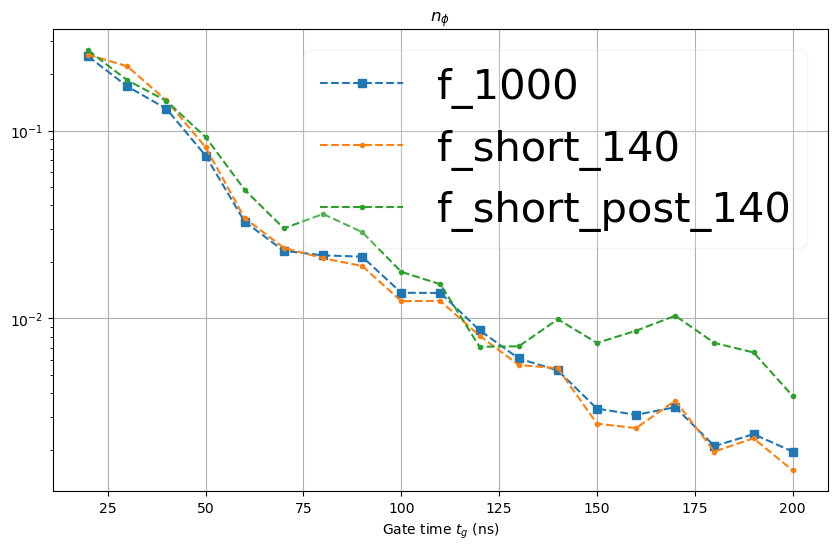

In [20]:
fig, ax = plt.subplots(figsize=(10,6))
plt.plot(f_phi['tg'], 10**f_phi['f_1000'], 's--', label=r'f_1000')
# plt.plot(f_phi['tg'], 10**f_phi['f_500'], '.--', label=r'f_500')
# plt.plot(f_phi['tg'], 10**f_charge_140, '.--', label=r'f_charge_140')
# plt.plot(f_phi['tg'], 10**f_70_all, '.--', label=r'f_70_all')
# plt.plot(f_phi['tg'], 10**f_80_all, '.--', label=r'f_80_all')
# plt.plot(f_phi['tg'], 10**f_90_all, '.--', label=r'f_90_all')
# plt.plot(f_phi['tg'], 10**f_100_all, '.--', label=r'f_100_all')
# plt.plot(f_phi['tg'], 10**f_130_all, '.--', label=r'f_130_all')
# plt.plot(f_phi['tg'], 10**f_all300_160, '.--', label=r'f_160')
# plt.plot(f_phi['tg'], 10**f_150_all, '.--', label=r'f_150_all')
plt.plot(f_phi['tg'], 10**f_short_140, '.--', label=r'f_short_140')
# plt.plot(f_phi['tg'], 10**f_short_120, '.--', label=r'f_short_120')
# plt.plot(f_phi['tg'], 10**f_short_100, '.--', label=r'f_short_100')
# plt.plot(f_phi['tg'], 10**f_all500_200, '.--', label=r'f_all500_200')
# plt.plot(f_phi['tg'], 10**f_all500_180, '.--', label=r'f_all500_180')
# plt.plot(f_phi['tg'], 10**f_test, '.--', label=r'f_170_10b')
# plt.plot(f_phi['tg'], 10**f_all500_170_20, '.--', label=r'f_all500_170_20')
plt.plot(f_phi['tg'], 10**f_short_post_140, '.--', label=r'f_short_post_140')
plt.yscale('log')
plt.title(r'$n_\phi$')
plt.xlabel('Gate time $t_g$ (ns)')
plt.grid()
legend = plt.legend( loc="best", fontsize=30 )
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

In [16]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

In [ ]:
f_50us_tphi_t1_29 = np.array([
-0.597837159026259, -1.0364488079341636, -1.30472009047845, -1.285174526891729 ,
-1.1911491932518665 ,
])
f_50us_tphi_t1_09 = np.array([
-0.6063112431542304, -1.100209088024563, -1.666978155178618, -1.7688117939637635 ,
-1.7310880067727425 ,
])

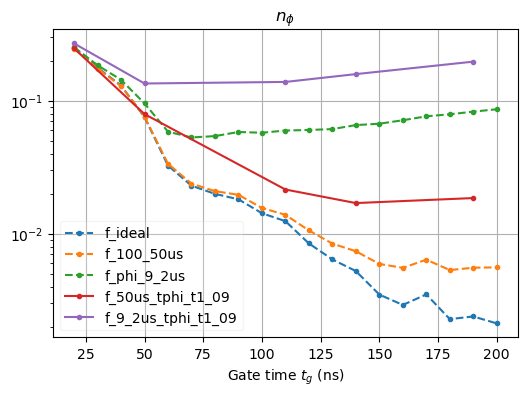

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
plt.plot(f_phi['tg'], 10**f_phi['f_ideal_160'], '.--', label=r'f_ideal')
plt.plot(f_phi['tg'], 10**f_phi['f_noise_100_50us'], '.--', label=r'f_100_50us')
plt.plot(f_phi['tg'], 10**f_phi['f_noise_9_2us'], '.--', label=r'f_phi_9_2us')
# plt.plot(tg7, 10**f_50us_tphi_t1_29, '.-', label=r'f_50us_tphi_t1_29')
plt.plot(tg7, 10**f_50us_tphi_t1_09, '.-', label=r'f_50us_tphi_t1_09')
plt.plot(tg7, 10**f_2us_tphi_t1_09, '.-', label=r'f_9_2us_tphi_t1_09')
plt.yscale('log')
plt.title(r'$n_\phi$')
plt.xlabel('Gate time $t_g$ (ns)')
plt.grid()
legend = plt.legend(    loc="best",    )
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

In [ ]:
f157_phi = np.array([-0.40106527, -0.75167091, -1.09786349, -1.19616409 ,-1.53194675 ,])
f500_phi = np.array([-0.40119934, -0.74385016, -1.08980239, -1.18396283 , -1.52970251 ,])
para_phi = np.array([
[10.003267, 0.24348, 0.211892, 0.444743, 0.499987] ,
[20.000082, 0.255455, 0.169295, 0.338178, 0.443775] ,
[30.009674, 0.226521, 0.166161, 0.34729, 0.404246] ,
[40.008273, 0.169565, 0.211625, 0.342425, 0.34903] ,
[60.010631, 0.201448, 0.117206, 0.300092, 0.339997] ,
])

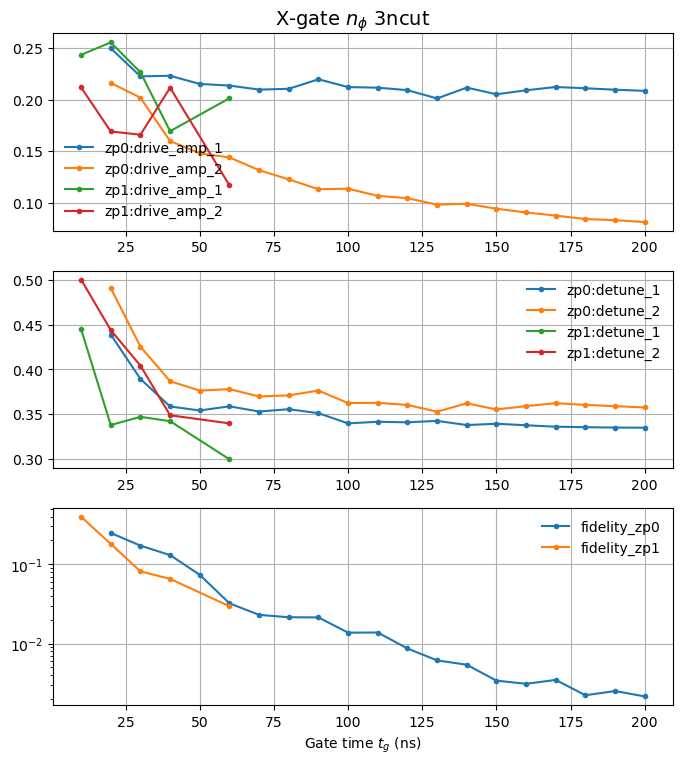

In [ ]:
fig, ax = plt.subplots(figsize=(8,8), nrows=3)
fig.suptitle(r'X-gate $n_\phi$ 3ncut', fontsize=14)
fig.subplots_adjust(top=0.95)
ax[0].plot(f_phi['tg'], f_phi['drive_amp_1'], '.-', label=r'zp0:drive_amp_1')
ax[0].plot(f_phi['tg'], f_phi['drive_amp_2'], '.-', label=r'zp0:drive_amp_2')
ax[1].plot(f_phi['tg'], f_phi['detune_1'], '.-', label=r'zp0:detune_1')
ax[1].plot(f_phi['tg'], f_phi['detune_2'], '.-', label=r'zp0:detune_2')
ax[2].plot(f_phi['tg'], 10**f_phi['f_500'], '.-', label=r'fidelity_zp0')

ax[0].plot(para_phi[:,0], para_phi[:,1], '.-', label=r'zp1:drive_amp_1')
ax[0].plot(para_phi[:,0], para_phi[:,2], '.-', label=r'zp1:drive_amp_2')
ax[1].plot(para_phi[:,0], para_phi[:,3], '.-', label=r'zp1:detune_1')
ax[1].plot(para_phi[:,0], para_phi[:,4], '.-', label=r'zp1:detune_2')
ax[2].plot(para_phi[:,0], 10**f500_phi, '.-', label=r'fidelity_zp1')

plt.xlabel('Gate time $t_g$ (ns)')
ax[2].set_yscale('log')
# ax[0].set_ylim(0.04, 0.05)
# ax[1].set_ylim(0.01, 0.02)
# ax[0].set_ylim(0.0065, 0.009)
# ax[1].set_ylim(0.01, 0.02)
ax[2].set_yscale('log')
for i in range(3):
    ax[i].grid()
    # ax[i].set_xlim(25, 40)
    # ax[i].set_xlim(150, 200)
    legend = ax[i].legend(loc='best', fontsize=10)
    legend.get_frame().set_alpha(0.01)  # 0.5 makes the legend 50% transparent